In [13]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px
from sklearn.preprocessing import MinMaxScaler
import plotly.graph_objects as go
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
import plotly.io as pio
pio.renderers.default = 'browser'


Data Collection

In [14]:
# Load datasets (update paths if needed)
yield_df = pd.read_csv("C:\\Users\\binit\\OneDrive\\Desktop\\capstone\\yield.csv")
rainfall_df = pd.read_csv("C:\\Users\\binit\\OneDrive\\Desktop\\capstone\\rainfall.csv")
pesticides_df = pd.read_csv("C:\\Users\\binit\\OneDrive\\Desktop\\capstone\\pesticides.csv")
temp_df = pd.read_csv("C:\\Users\\binit\\OneDrive\\Desktop\\capstone\\temp.csv")

# Print dataset shapes
print("Yield Data Shape:", yield_df.shape)
print("Rainfall Data Shape:", rainfall_df.shape)
print("Pesticide Data Shape:", pesticides_df.shape)
print("Temperature Data Shape:", temp_df.shape)


Yield Data Shape: (56717, 12)
Rainfall Data Shape: (6727, 3)
Pesticide Data Shape: (4349, 7)
Temperature Data Shape: (71311, 3)


Data Cleaning nad Processing

In [18]:
import numpy as np
import pandas as pd

# Load crop yield data
df_yield = pd.read_csv("C:\\Users\\binit\\OneDrive\\Desktop\\capstone\\yield.csv")
df_yield = df_yield.rename(columns={"Value": "hg/ha_yield"})

# Drop unnecessary columns
df_yield = df_yield.drop(['Year Code','Element Code','Element','Area Code','Domain Code','Domain','Unit','Item Code'], axis=1)


df_yield

,Area,Item,Year,hg/ha_yield
0,Afghanistan,Maize,1961,14000
1,Afghanistan,Maize,1962,14000
2,Afghanistan,Maize,1963,14260
3,Afghanistan,Maize,1964,14257
4,Afghanistan,Maize,1965,14400
...,...,...,...,...
56712,Zimbabwe,Wheat,2012,24420
56713,Zimbabwe,Wheat,2013,22888
56714,Zimbabwe,Wheat,2014,21357
56715,Zimbabwe,Wheat,2015,19826


In [19]:
df_rain = pd.read_csv("C:\\Users\\binit\\OneDrive\\Desktop\\capstone\\rainfall.csv")
df_rain = df_rain.rename(columns={" Area": 'Area'})  # handle leading space

# Convert rainfall to numeric
df_rain['average_rain_fall_mm_per_year'] = pd.to_numeric(df_rain['average_rain_fall_mm_per_year'], errors='coerce')
df_rain = df_rain.dropna()

In [20]:
yield_df = pd.merge(df_yield, df_rain, on=['Year', 'Area'])


In [22]:
df_pes = pd.read_csv("C:\\Users\\binit\\OneDrive\\Desktop\\capstone\\pesticides.csv")
df_pes = df_pes.rename(columns={"Value": "pesticides_tonnes"})
df_pes = df_pes.drop(['Element','Domain','Unit','Item'], axis=1)

yield_df = pd.merge(yield_df, df_pes, on=['Year', 'Area'])


In [24]:
avg_temp = pd.read_csv("C:\\Users\\binit\\OneDrive\\Desktop\\capstone\\temp.csv")
avg_temp = avg_temp.rename(columns={"year": "Year", "country": "Area"})

yield_df = pd.merge(yield_df, avg_temp, on=['Area', 'Year'])
print("Final Dataset Shape:", yield_df.shape)
yield_df.head()



Final Dataset Shape: (28242, 7)


,Area,Item,Year,hg/ha_yield,average_rain_fall_mm_per_year,pesticides_tonnes,avg_temp
0,Albania,Maize,1990,36613,1485.0,121.0,16.37
1,Albania,Maize,1991,29068,1485.0,121.0,15.36
2,Albania,Maize,1992,24876,1485.0,121.0,16.06
3,Albania,Maize,1993,24185,1485.0,121.0,16.05
4,Albania,Maize,1994,25848,1485.0,201.0,16.96


In [25]:
# Null check
print("Missing values:\n", yield_df.isnull().sum())

# Summary stats
yield_df.describe()

# Unique crops
print("Crop Types:\n", yield_df['Item'].value_counts())

# Unique countries
print("Countries:\n", yield_df['Area'].nunique())


Missing values:
 Area                             0
Item                             0
Year                             0
hg/ha_yield                      0
average_rain_fall_mm_per_year    0
pesticides_tonnes                0
avg_temp                         0
dtype: int64
Crop Types:
 Item
Potatoes                4276
Maize                   4121
Wheat                   3857
Rice, paddy             3388
Soybeans                3223
Sorghum                 3039
Sweet potatoes          2890
Cassava                 2045
Yams                     847
Plantains and others     556
Name: count, dtype: int64
Countries:
 101


Exploratory Data Analysis

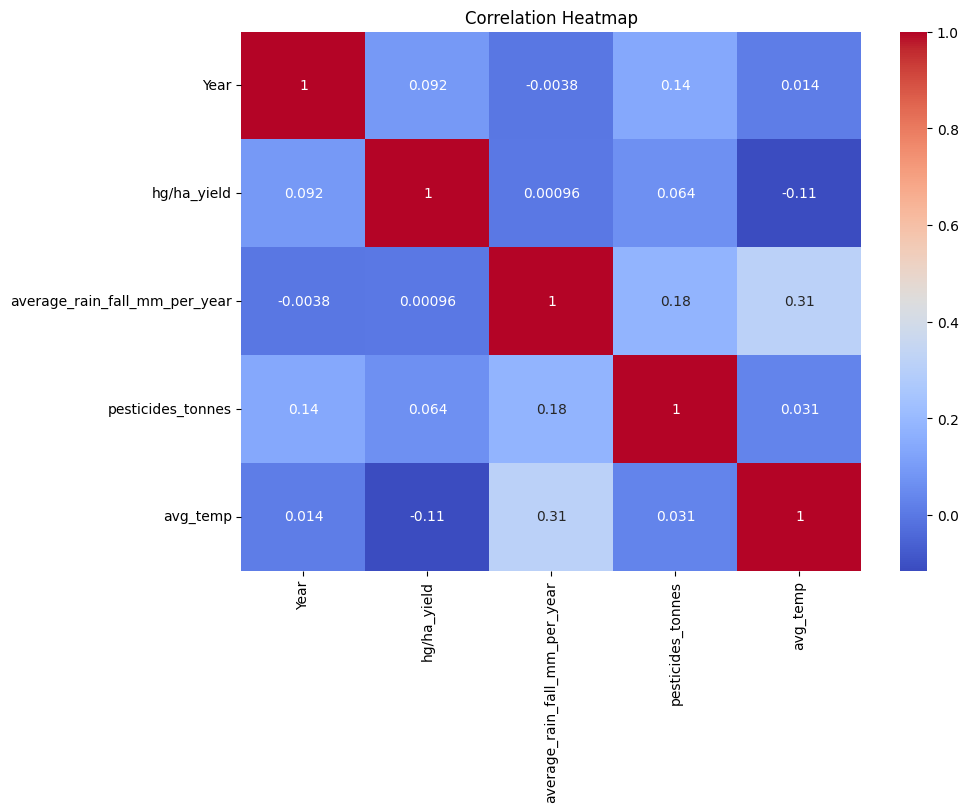

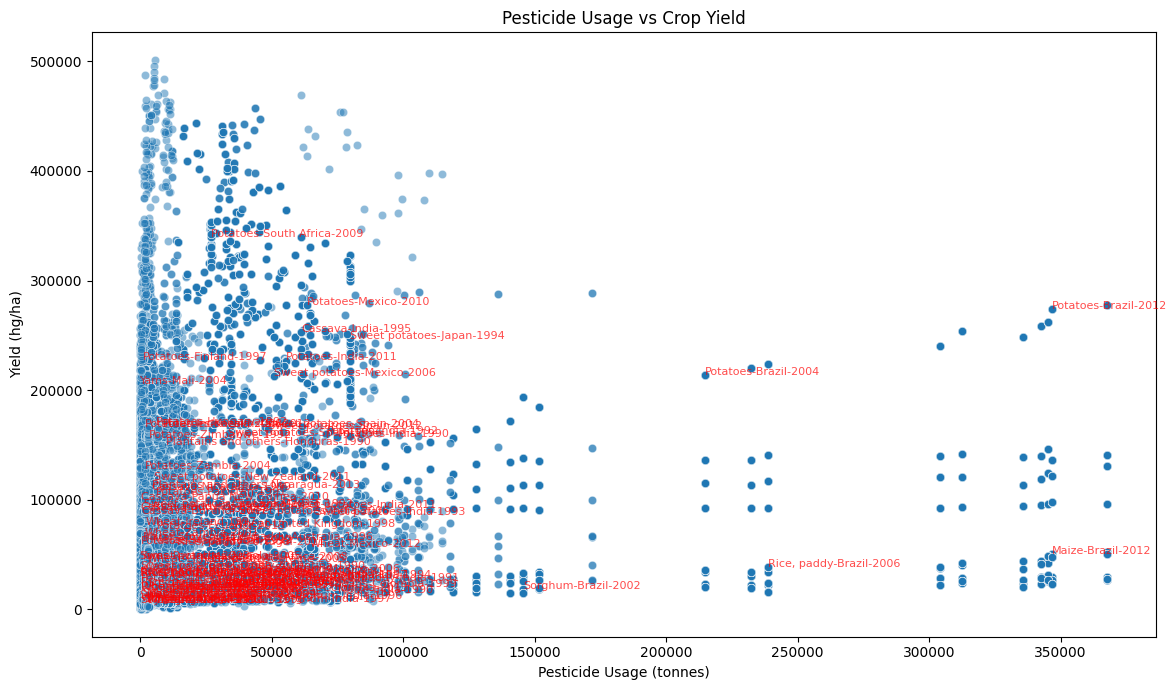

In [26]:
# Correlation Analysis
numeric_yield_df = yield_df.select_dtypes(include=['number'])
plt.figure(figsize=(10, 7))
sns.heatmap(numeric_yield_df.corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

#yield_df = yield_df.rename(columns={'hg/ha_yield': 'hg_ha_yield'})
#sns.scatterplot(x='pesticides_tonnes', y='hg_ha_yield', data=yield_df)
#plt.title('Pesticide Usage vs Crop Yield')
#plt.show()

yield_df = yield_df.rename(columns={'hg/ha_yield': 'hg_ha_yield'})
sample_df = yield_df.sample(100, random_state=42)
plt.figure(figsize=(12, 7))
sns.scatterplot(x='pesticides_tonnes', y='hg_ha_yield', data=yield_df, alpha=0.5)
for _, row in sample_df.iterrows():
    label = f"{row['Item']}-{row['Area']}-{int(row['Year'])}"
    plt.text(row['pesticides_tonnes'] + 0.5, row['hg_ha_yield'], label, fontsize=8, alpha=0.7, color = 'red')
plt.title('Pesticide Usage vs Crop Yield')
plt.xlabel('Pesticide Usage (tonnes)')
plt.ylabel('Yield (hg/ha)')
plt.tight_layout()
plt.show()



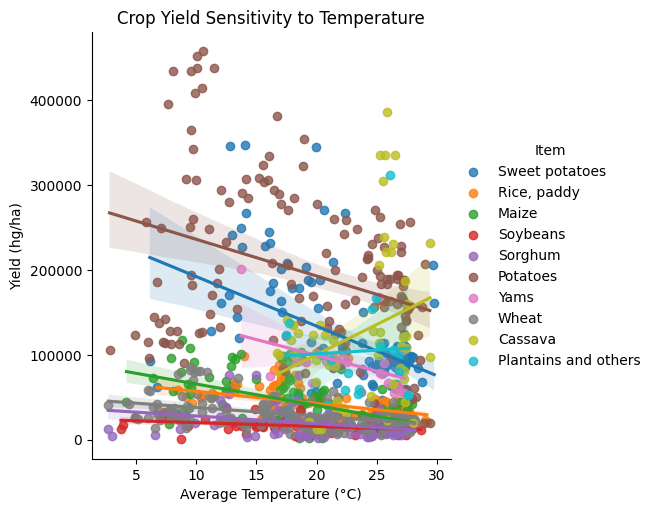

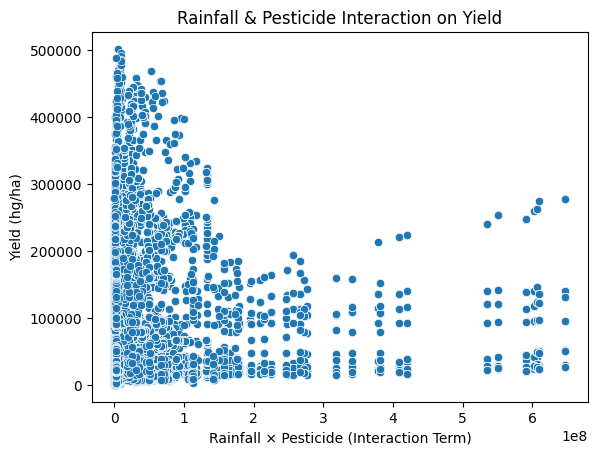

In [27]:
sns.lmplot(x='avg_temp', y='hg_ha_yield', hue='Item', data=yield_df.sample(1000))
plt.title('Crop Yield Sensitivity to Temperature')
plt.xlabel('Average Temperature (°C)')
plt.ylabel('Yield (hg/ha)')
plt.show()

yield_df['rain_pest_interaction'] = yield_df['average_rain_fall_mm_per_year'] * yield_df['pesticides_tonnes']
sns.scatterplot(x='rain_pest_interaction', y='hg_ha_yield', data=yield_df)
plt.title('Rainfall & Pesticide Interaction on Yield')
plt.xlabel('Rainfall × Pesticide (Interaction Term)')
plt.ylabel('Yield (hg/ha)')
plt.show()

In [28]:
yield_df = yield_df.rename(columns={'hg/ha_yield': 'hg_ha_yield'})
conditions = yield_df.groupby(['Area', 'Item']).agg({
    'hg_ha_yield': 'mean',
    'average_rain_fall_mm_per_year': 'mean',
    'pesticides_tonnes': 'mean',
    'avg_temp': 'mean'
}).reset_index()
scaler = MinMaxScaler()
conditions['yield_scaled'] = scaler.fit_transform(conditions[['hg_ha_yield']])
conditions['rain_scaled'] = scaler.fit_transform(conditions[['average_rain_fall_mm_per_year']])
conditions['pesticide_scaled'] = 1 - scaler.fit_transform(conditions[['pesticides_tonnes']])  
conditions['temp_scaled'] = conditions['avg_temp'].apply(lambda x: 1 if 15 <= x <= 25 else 0.5) 
conditions['Growth_Score'] = (0.4 * conditions['yield_scaled'] + 0.3 * conditions['rain_scaled'] + 0.2 * conditions['pesticide_scaled'] + 0.1 * conditions['temp_scaled'])
best_crops = conditions.loc[conditions.groupby('Area')['Growth_Score'].idxmax()].reset_index(drop=True)
#print(best_crops[['Area', 'Item', 'Growth_Score']].sort_values(by='Growth_Score', ascending=False).head(10))
crop_colors = {
    "Potatoes": "#FFD700",             
    "Cassava": "#FF7F50",              
    "Wheat": "#C2B280",                
    "Sweet potatoes": "#DA70D6",      
    "Yams": "#FFA07A",                 
    "Plantains and others": "#20B2AA", 
    "Maize": "#FF69B4"                 
}
crop_to_id = {crop: idx for idx, crop in enumerate(crop_colors.keys())}
best_crops['zval'] = best_crops['Item'].map(crop_to_id)
colorscale = [
    [i / (len(crop_colors)-1), color]
    for i, color in enumerate(crop_colors.values())
]
fig = go.Figure(data=go.Choropleth(locations=best_crops['Area'],locationmode='country names',z=best_crops['zval'],text=best_crops['Item'],customdata=best_crops[['Growth_Score']].values, 
    colorscale=colorscale,colorbar=dict(tickvals=list(crop_to_id.values()),ticktext=list(crop_to_id.keys()),title="Best Crop"),
    hovertemplate=(
        "<b>%{location}</b><br>"
        "Best Crop: %{text}<br>"
        "Growth Score: %{customdata:.3f}<extra></extra>"
    ),
    marker_line_color='black',
    marker_line_width=0.5,
    showscale=True
))
fig.update_geos(projection_type='orthographic',showland=True,landcolor="lightgray",showocean=True,oceancolor="lightblue")
fig.update_layout(
    title_text="<b>Best Crops by Country</b>",
    title_x=0.5,
    title_xanchor='center', 
    font=dict(family="Trebuchet MS", color="black"),
    title_font=dict(size=22, family="Georgia"),
    margin={"r": 0, "t": 60, "l": 0, "b": 0}
)
fig.show()


C:\Users\binit\AppData\Local\Temp\ipykernel_18936\3989813167.py:31: DeprecationWarning:

The library used by the *country names* `locationmode` option is changing in an upcoming version. Country names in existing plots may not work in the new version. To ensure consistent behavior, consider setting `locationmode` to *ISO-3*.



In [29]:
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
import plotly.graph_objects as go
import plotly.colors as pc

# STEP 1: Calculate best crop per country
yield_df = yield_df.rename(columns={'hg/ha_yield': 'hg_ha_yield'})

conditions = yield_df.groupby(['Area', 'Item']).agg({
    'hg_ha_yield': 'mean',
    'average_rain_fall_mm_per_year': 'mean',
    'pesticides_tonnes': 'mean',
    'avg_temp': 'mean'
}).reset_index()

scaler = MinMaxScaler()
conditions['yield_scaled'] = scaler.fit_transform(conditions[['hg_ha_yield']])
conditions['rain_scaled'] = scaler.fit_transform(conditions[['average_rain_fall_mm_per_year']])
conditions['pesticide_scaled'] = 1 - scaler.fit_transform(conditions[['pesticides_tonnes']])
conditions['temp_scaled'] = conditions['avg_temp'].apply(lambda x: 1 if 15 <= x <= 25 else 0.5)

conditions['Growth_Score'] = (
    0.4 * conditions['yield_scaled'] +
    0.3 * conditions['rain_scaled'] +
    0.2 * conditions['pesticide_scaled'] +
    0.1 * conditions['temp_scaled']
)

best_crops = conditions.loc[conditions.groupby('Area')['Growth_Score'].idxmax()].reset_index(drop=True)

# STEP 2: Sort crops by frequency of selection as best crop
sorted_crops = best_crops['Item'].value_counts().index.tolist()

# STEP 3: Assign colors and numeric z values
crop_to_id = {crop: idx for idx, crop in enumerate(sorted_crops)}
best_crops['zval'] = best_crops['Item'].map(crop_to_id)

# Dynamic color palette (extendable for many crops)
color_pool = pc.qualitative.Plotly + pc.qualitative.Pastel + pc.qualitative.Dark24
crop_colors = {crop: color_pool[i % len(color_pool)] for i, crop in enumerate(sorted_crops)}

colorscale = [
    [i / (len(crop_colors) - 1), crop_colors[crop]]
    for i, crop in enumerate(sorted_crops)
]

# STEP 4: Create the 3D globe map
fig = go.Figure(data=go.Choropleth(
    locations=best_crops['Area'],
    locationmode='country names',
    z=best_crops['zval'],
    text=best_crops['Item'],
    customdata=best_crops[['Growth_Score']].values,
    colorscale=colorscale,
    colorbar=dict(
        tickvals=list(crop_to_id.values()),
        ticktext=list(crop_to_id.keys()),
        title="Best Crop"
    ),
    hovertemplate="<b>%{location}</b><br>Best Crop: %{text}<br>Growth Score: %{customdata:.3f}<extra></extra>",
    marker_line_color='black',
    marker_line_width=0.5,
    showscale=True
))

# STEP 5: Configure globe view
fig.update_geos(
    projection_type='orthographic',
    showland=True,
    landcolor="lightgray",
    showocean=True,
    oceancolor="lightblue"
)

# STEP 6: Layout and styling
fig.update_layout(
    title={
        'text': "<b>🌾 What Grows Best Where?</b><br><sub style='color:gray;'>Top Crops per Country Based on Ideal Growth Conditions</sub>",
        'x': 0.5,
        'xanchor': 'center'
    },
    font=dict(family="Trebuchet MS", color="black"),
    title_font=dict(size=22, family="Georgia"),
    margin={"r": 0, "t": 60, "l": 0, "b": 0}
)

fig.show()


C:\Users\binit\AppData\Local\Temp\ipykernel_18936\3053779787.py:48: DeprecationWarning:

The library used by the *country names* `locationmode` option is changing in an upcoming version. Country names in existing plots may not work in the new version. To ensure consistent behavior, consider setting `locationmode` to *ISO-3*.



In [30]:
# Interaction features
yield_df['temp_rain_interaction'] = yield_df['avg_temp'] * yield_df['average_rain_fall_mm_per_year']

# Encoding categorical variables
yield_df['Crop_Type_Code'] = yield_df['Item'].astype('category').cat.codes
yield_df['Country_Code'] = yield_df['Area'].astype('category').cat.codes

# Check data after feature engineering
print(yield_df.head())
yield_df.to_csv("yield_df.csv", index=False)

      Area   Item  Year  hg_ha_yield  average_rain_fall_mm_per_year  \
0  Albania  Maize  1990        36613                         1485.0   
1  Albania  Maize  1991        29068                         1485.0   
2  Albania  Maize  1992        24876                         1485.0   
3  Albania  Maize  1993        24185                         1485.0   
4  Albania  Maize  1994        25848                         1485.0   

   pesticides_tonnes  avg_temp  rain_pest_interaction  temp_rain_interaction  \
0              121.0     16.37               179685.0               24309.45   
1              121.0     15.36               179685.0               22809.60   
2              121.0     16.06               179685.0               23849.10   
3              121.0     16.05               179685.0               23834.25   
4              201.0     16.96               298485.0               25185.60   

   Crop_Type_Code  Country_Code  
0               1             0  
1               1       

Machine Learning Modelling 

In [31]:
# Machine Learning Models
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Define features and target
features = ['average_rain_fall_mm_per_year','pesticides_tonnes','avg_temp',
            'rain_pest_interaction','temp_rain_interaction','Crop_Type_Code','Country_Code']
target = 'hg_ha_yield'

X = yield_df[features]
y = yield_df[target]

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Random Forest model
rf = RandomForestRegressor(n_estimators=100)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

# XGBoost model
xgb = XGBRegressor()
xgb.fit(X_train, y_train)
y_pred_xgb = xgb.predict(X_test)


In [32]:
# Evaluation metrics
def evaluate_model(y_test, y_pred, model_name):
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)
    print(f"{model_name} Results:")
    print(f"Mean Absolute Error (MAE): {mae:.2f}")
    print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
    print(f"R² Score: {r2:.2f}\n")

evaluate_model(y_test, y_pred_rf, "Random Forest")
evaluate_model(y_test, y_pred_xgb, "XGBoost")


Random Forest Results:
Mean Absolute Error (MAE): 5597.91
Root Mean Squared Error (RMSE): 13682.20
R² Score: 0.97

XGBoost Results:
Mean Absolute Error (MAE): 8757.69
Root Mean Squared Error (RMSE): 15466.12
R² Score: 0.97



In [33]:
import os

# Create 'models' folder in locaal
os.makedirs("models", exist_ok=True)


In [34]:
import joblib

# Save the trained Random Forest model
joblib.dump(rf, "models/crop_yield_rf_model.pkl")


['models/crop_yield_rf_model.pkl']